- Perform a stratified split of the dataset
- Train and compare the performance of the individual level-1 classifiers and the meta-classifier
- Report the final accuracies (for the individual level-1 classifiers and the meta-classifier) using both Predictions and Scores
- Report the final accuracies (for the individual level-1 classifiers and the meta-classifier) when no split of the training set is done

In [1]:
import numpy as np

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

import pandas as pd

from scipy.io import loadmat

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.metrics import accuracy_score

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

Load the Dataset

In [2]:
data = loadmat("../Datasets/dataset.mat")
data_tr = data["data_tr"]
data_te = data["data_te"]
labels_tr = data["labels_tr"].ravel()
labels_te = data["labels_te"].ravel()
print(data_tr)

[[ 0.24472039 -0.59760684]
 [ 0.59999055 -0.6002798 ]
 [-0.00403589 -0.00990386]
 ...
 [ 0.94690674  1.32727933]
 [-1.26308963 -1.4394436 ]
 [ 0.82838682 -1.17415239]]


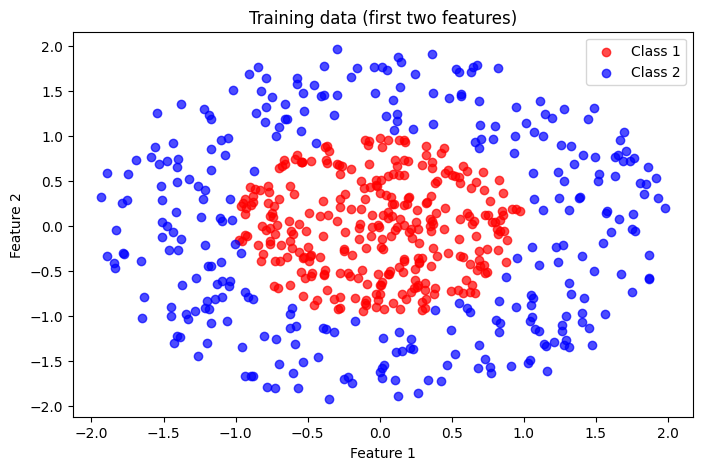

In [3]:
# 2. QUICK VISUALIZATION OF FIRST TWO FEATURES

plt.figure(figsize=(8, 5))
plt.scatter(data_tr[labels_tr == 1, 0], data_tr[labels_tr == 1, 1], c="r", label="Class 1", alpha=0.7)
plt.scatter(data_tr[labels_tr == 2, 0], data_tr[labels_tr == 2, 1], c="b", label="Class 2", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training data (first two features)")
plt.legend()
plt.show()


Splitting the data

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    data_tr,
    labels_tr,
    test_size=0.3,
    random_state=42,
    stratify=labels_tr
)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)


(420, 2) (180, 2)
(420,) (180,)


Training the model

Level-1 classifiers

In [5]:
# Cross Validation Technique For Model Selection 
cv = StratifiedKFold(n_splits=5, random_state=42,shuffle=True)

# SVM RBF

param_svm_rbf = {
    "C":[0.2, 1, 10],
    "gamma":["scale", "auto", 0.1, 0.01]
}

grid_svm_rbf = GridSearchCV(SVC(kernel='rbf',probability=True), param_svm_rbf, cv=cv, scoring="accuracy", n_jobs=-1)
grid_svm_rbf.fit(X_train, y_train)

best_svm_rbf = grid_svm_rbf.best_estimator_

# SVM Polynomial
param_svm_poly = {
    "C": [0.1, 1, 10],
    "degree": [2, 3, 4],
    "gamma": ['scale', 'auto', 0.1, 0.01]
} 

grid_svm_poly =GridSearchCV(SVC(kernel="poly", probability=True), param_svm_poly, cv=cv, scoring='accuracy',n_jobs=-1)
grid_svm_poly.fit(X_train, y_train)

best_svm_poly = grid_svm_poly.best_estimator_


# Decision Tree

param_tree = {
    "max_depth":[5, 10, 20, None],
    "min_samples_split":[20, 5, 10]
}

grid_tree = GridSearchCV(DecisionTreeClassifier(), param_tree, cv=cv, scoring='accuracy',n_jobs=-1)

grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_


# Random Forest
param_rf = {
    "n_estimators": [50, 100, 200],
    "min_samples_split":[20, 5, 10]
    
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=cv, scoring="accuracy", n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_


# Collect models
models = [best_svm_poly, best_svm_rbf, best_tree, best_rf]


Evaluate Level-1 Models on a Test set

In [6]:
# EVALUATE LEVEL-1 CLASSIFIERS ON TEST SET
print("\nLEVEL-1 CLASSIFIERS TEST PERFORMANCE")
level1_results = {}

for name, model in enumerate(models):
    y_pred = model.predict(data_te)
    acc = accuracy_score(labels_te, y_pred)
    level1_results[name] = acc

    print(f"{model}:\naccuracy = {acc:.4f}")
    print(confusion_matrix(labels_te, y_pred))
    print(classification_report(labels_te, y_pred))
    print("-" * 60)


LEVEL-1 CLASSIFIERS TEST PERFORMANCE
SVC(C=10, degree=2, kernel='poly', probability=True):
accuracy = 0.9917
[[300   0]
 [  5 295]]
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       300
           2       1.00      0.98      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

------------------------------------------------------------
SVC(C=10, probability=True):
accuracy = 0.9883
[[300   0]
 [  7 293]]
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       300
           2       1.00      0.98      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

------------------------------------------------------------
DecisionTreeClassifie

Building Meta Features For The Meta Classifier

In [7]:
# PREPARE META-CLASSIFIER INPUT ON TEST SET

n = len(models)
predictions_te = np.zeros((len(data_te), n))
scores_te = np.zeros((len(data_te), n))

for i,  model in enumerate(models):
    predictions_te[:, i] = model.predict(data_te)
    scores_te[:, i] = model.predict_proba(data_te)[:, 1]


In [8]:
# TRAIN META-CLASSIFIERS ON FOLD2 OUTPUTS
# The skeleton suggests AdaBoost as meta-classifier.


predictions_val = np.zeros((len(X_val), n))
scores_val= np.zeros((len(X_val), n))

for i,  model in enumerate(models):
    predictions_val[:, i] = model.predict(X_val)

    # probability of positive class / second class
    # assumes binary classification
    proba = model.predict_proba(X_val)
    scores_val[:, i] = proba[:, 1]
meta_class_pred = AdaBoostClassifier(n_estimators=50, random_state=42, learning_rate=0.1)
meta_class_pred.fit(predictions_val, y_val)

meta_class_scores = AdaBoostClassifier(n_estimators=50, random_state=42, learning_rate=0.1)
meta_class_scores.fit(scores_val, y_val)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [9]:
# EVALUATE META-CLASSIFIER ON TEST SET

meta_pred_test = meta_class_pred.predict(predictions_te)
meta_score_test = meta_class_scores.predict(scores_te)

acc_meta_predictions = accuracy_score(labels_te, meta_pred_test)
acc_meta_scores = accuracy_score(labels_te, meta_score_test)

print("\n===> META-CLASSIFIER TEST PERFORMANCE <===")
print(f"Meta-classifier using PREDICTIONS: accuracy = {acc_meta_predictions:.4f}")
print(confusion_matrix(labels_te, meta_pred_test))
print(classification_report(labels_te, meta_pred_test))
print("-" * 60)

print(f"Meta-classifier using SCORES: accuracy = {acc_meta_scores:.4f}")
print(confusion_matrix(labels_te, meta_score_test))
print(classification_report(labels_te, meta_score_test))
print("-" * 60)


===> META-CLASSIFIER TEST PERFORMANCE <===
Meta-classifier using PREDICTIONS: accuracy = 0.9917
[[300   0]
 [  5 295]]
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       300
           2       1.00      0.98      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

------------------------------------------------------------
Meta-classifier using SCORES: accuracy = 0.9967
[[300   0]
 [  2 298]]
              precision    recall  f1-score   support

           1       0.99      1.00      1.00       300
           2       1.00      0.99      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

------------------------------------------------------------


Training All The Models On Whole Dataset Without Splitting

In [13]:
models_full = []

svm_rbf_full = grid_svm_rbf.fit(data_tr, labels_tr)
best_svm_rbf_full = svm_rbf_full.best_estimator_

models_full.append(("SVM-RBF", best_svm_rbf_full))

svm_poly_full = grid_svm_poly.fit(data_tr, labels_tr)
best_svm_poly_full = svm_poly_full.best_estimator_
models_full.append(("SVM-Poly", best_svm_poly_full))

tree_full = grid_tree.fit(data_tr, labels_tr)
best_tree_full = tree_full.best_estimator_
models_full.append(("Decision Tree", best_tree_full))

rf_full = grid_rf.fit(data_tr, labels_tr)
best_rf_full = rf_full.best_estimator_
models_full.append(("Random Forest", best_rf_full))

predictions_tr_full = np.zeros((len(data_tr), n))
scores_tr_full = np.zeros((len(data_tr), n))

for i, (name, model) in enumerate(models_full):
    predictions_tr_full[:, i] = model.predict(data_tr)
    scores_tr_full[:, i] = model.predict_proba(data_tr)[:, 1]

meta_no_split_predictions = meta_class_pred.fit(predictions_tr_full, labels_tr)
meta_no_split_scores = meta_class_scores.fit(scores_tr_full, labels_tr)


# Build test meta-features from full-trained level-1 models
predictions_te_full = np.zeros((len(data_te), n))
scores_te_full = np.zeros((len(data_te), n))

for i, (name, model) in enumerate(models_full):
    predictions_te_full[:, i] = model.predict(data_te)
    scores_te_full[:, i] = model.predict_proba(data_te)[:, 1]

meta_no_split_pred_test = meta_no_split_predictions.predict(predictions_te_full)
meta_no_split_score_test = meta_no_split_scores.predict(scores_te_full)

acc_meta_no_split_predictions = accuracy_score(labels_te, meta_no_split_pred_test)
acc_meta_no_split_scores = accuracy_score(labels_te, meta_no_split_score_test)

print("\n===> META-CLASSIFIER PERFORMANCE WITHOUT SPLITTING TRAINING SET <===")
print(f"No-split meta-classifier using PREDICTIONS: accuracy = {acc_meta_no_split_predictions:.4f}")
print(confusion_matrix(labels_te, meta_no_split_pred_test))
print(classification_report(labels_te, meta_no_split_pred_test))
print("-" * 60)

print(f"No-split meta-classifier using Probability SCORES: accuracy = {acc_meta_no_split_scores:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(labels_te, meta_no_split_score_test)}")
print(classification_report(labels_te, meta_no_split_score_test))
print("-" * 60)


# 11. FINAL SUMMARY TABLE

print("\n=== FINAL ACCURACY SUMMARY ===")
for name, acc in level1_results.items():
    print(f"{name}: {acc:.4f}")

print(f"Meta-classifier using Predictions: {acc_meta_predictions:.4f}")
print(f"Meta-classifier using Probability Scores: {acc_meta_scores:.4f}")
print(f"No-split meta using Predictions: {acc_meta_no_split_predictions:.4f}")
print(f"No-split meta using Scores: {acc_meta_no_split_scores:.4f}")


===> META-CLASSIFIER PERFORMANCE WITHOUT SPLITTING TRAINING SET <===
No-split meta-classifier using PREDICTIONS: accuracy = 0.9683
[[289  11]
 [  8 292]]
              precision    recall  f1-score   support

           1       0.97      0.96      0.97       300
           2       0.96      0.97      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

------------------------------------------------------------
No-split meta-classifier using Probability SCORES: accuracy = 1.0000
Confusion Matrix:
[[300   0]
 [  0 300]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

--------------------